# Age-18 Activity Outcome EDA

This notebook examines the distribution and class balance of the four-category May 2009 activity outcome constructed in Stage 1. The records examined here form the valid Stage 1 outcome sample; later modelling restrictions are applied in the modelling-dataset construction stage.

# Part 1: Outcome Sample

In [1]:
# 1: Set project paths and import packages

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

working_directory = Path.cwd().resolve()

project_root = next(
    (
        directory
        for directory in (
            working_directory,
            *working_directory.parents,
        )
        if (
            directory
            / "data_derived"
            / "stage_1_outcome_construction"
        ).exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "The Stage 1 outcome directory could not be located."
    )

stage_1_output_directory = (
    project_root
    / "data_derived"
    / "stage_1_outcome_construction"
)

outcome_path = (
    stage_1_output_directory
    / "age18_activity_outcome.csv"
)

sample_flow_path = (
    stage_1_output_directory
    / "age18_activity_outcome_sample_flow.csv"
)

distribution_path = (
    stage_1_output_directory
    / "age18_activity_outcome_distribution.csv"
)

codebook_path = (
    stage_1_output_directory
    / "age18_activity_outcome_codebook.csv"
)

required_paths = [
    outcome_path,
    sample_flow_path,
    distribution_path,
    codebook_path,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Missing Stage 1 file(s): "
        + ", ".join(path.name for path in missing_paths)
    )

print("Project root located.")
print(
    "Stage 1 outcome directory:",
    stage_1_output_directory.relative_to(project_root),
)


Project root located.
Stage 1 outcome directory: data_derived\stage_1_outcome_construction


In [2]:
# 2: Load the Stage 1 outcome files

age18_outcome = pd.read_csv(
    outcome_path,
    dtype={
        "NSID": "string",
        "age18_outcome_code": "int64",
        "age18_outcome": "string",
    },
)

sample_flow = pd.read_csv(
    sample_flow_path
)

stored_distribution = pd.read_csv(
    distribution_path
)

outcome_codebook = pd.read_csv(
    codebook_path,
    dtype={
        "included_in_outcome": "boolean",
    },
)

outcome_order = [
    "Education",
    "Employment",
    "Apprenticeship or training",
    "Unemployment or inactivity (NEET)",
]

expected_code_label_mapping = {
    1: "Education",
    4: "Employment",
    5: "Apprenticeship or training",
    6: "Unemployment or inactivity (NEET)",
}


In [3]:
# 3: Check the retained sample and outcome coding

valid_outcome_n = int(
    sample_flow.loc[
        sample_flow["stage"].eq("Valid primary outcome"),
        "count",
    ].iloc[0]
)

observed_code_label_mapping = (
    age18_outcome[
        [
            "age18_outcome_code",
            "age18_outcome",
        ]
    ]
    .drop_duplicates()
    .sort_values("age18_outcome_code")
    .set_index("age18_outcome_code")["age18_outcome"]
    .to_dict()
)

if len(age18_outcome) != valid_outcome_n:
    raise ValueError(
        "The participant-level outcome did not match "
        "the valid sample count."
    )

if not age18_outcome["NSID"].is_unique:
    raise ValueError(
        "Duplicate participant identifiers were found."
    )

if age18_outcome.isna().any().any():
    raise ValueError(
        "Missing values were found in the retained outcome sample."
    )

if observed_code_label_mapping != expected_code_label_mapping:
    raise ValueError(
        "The saved outcome code-label mapping was incorrect."
    )

included_codebook = (
    outcome_codebook.loc[
        outcome_codebook["included_in_outcome"],
        [
            "raw_code",
            "source_label",
            "analysis_label",
            "observed_count",
        ],
    ]
    .copy()
    .sort_values("raw_code")
    .reset_index(drop=True)
)

included_codebook["raw_code"] = (
    included_codebook["raw_code"]
    .astype("int64")
)

codebook_mapping = (
    included_codebook
    .set_index("raw_code")["analysis_label"]
    .to_dict()
)

if codebook_mapping != expected_code_label_mapping:
    raise ValueError(
        "The codebook mapping did not match the saved outcome."
    )

if included_codebook["observed_count"].sum() != valid_outcome_n:
    raise ValueError(
        "The included codebook counts did not match "
        "the retained outcome sample."
    )

sample_flow_display = sample_flow.copy()
sample_flow_display["percentage_of_source"] = (
    sample_flow_display["percentage_of_source"]
    .round(2)
)

print("Outcome sample")
print("--------------")
print("Retained participants:", f"{len(age18_outcome):,}")
print("Unique NSID:", f"{age18_outcome['NSID'].nunique():,}")
print("Duplicate NSID:", age18_outcome["NSID"].duplicated().sum())
print("Missing values:", age18_outcome.isna().sum().sum())

print()
print("Sample flow")
print("-----------")
display(sample_flow_display)

print("Outcome coding")
print("--------------")
display(included_codebook)


Outcome sample
--------------
Retained participants: 9,767
Unique NSID: 9,767
Duplicate NSID: 0
Missing values: 0

Sample flow
-----------


,stage,count,percentage_of_source
0,Monthly activity source file,11811,100.00
1,Insufficient information,2044,17.31
2,Missing endpoint value,0,0.00
3,Valid primary outcome,9767,82.69


Outcome coding
--------------


,raw_code,source_label,analysis_label,observed_count
0,1,Education,Education,5132
1,4,Employed,Employment,2831
2,5,Apprenticeship/training,Apprenticeship or training,524
3,6,Unemployed/Inactive (NEET),Unemployment or inactivity (NEET),1280


## Outcome Sample

The source dataset contained 11,811 participants. A total of 2,044 participants (17.31%) had insufficient information for the May 2009 activity outcome, leaving 9,767 participants (82.69%) in the valid Stage 1 outcome sample. The retained dataset contained one record per participant, with no duplicate identifiers or missing outcome values.

The four included source codes corresponded to Education, Employment, Apprenticeship or training, and Unemployment or inactivity (NEET). Category counts in the codebook matched those in the participant-level outcome dataset.

# Part 2: Outcome Distribution and Class Balance


In [4]:
# 1: Calculate the outcome distribution and class-balance indicators

observed_distribution = (
    age18_outcome["age18_outcome"]
    .value_counts()
    .reindex(outcome_order)
    .rename_axis("age18_outcome")
    .reset_index(name="count")
)

observed_distribution["percentage"] = (
    observed_distribution["count"]
    / valid_outcome_n
    * 100
)

stored_distribution_ordered = (
    stored_distribution
    .set_index("age18_outcome")
    .reindex(outcome_order)
    .reset_index()
)

if observed_distribution["count"].tolist() != (
    stored_distribution_ordered["count"].tolist()
):
    raise ValueError(
        "The observed and stored outcome counts did not match."
    )

if not np.allclose(
    observed_distribution["percentage"],
    stored_distribution_ordered["percentage"],
):
    raise ValueError(
        "The observed and stored outcome percentages did not match."
    )

largest_class = observed_distribution.loc[
    observed_distribution["count"].idxmax(),
    "age18_outcome",
]

smallest_class = observed_distribution.loc[
    observed_distribution["count"].idxmin(),
    "age18_outcome",
]

largest_class_n = int(
    observed_distribution["count"].max()
)

smallest_class_n = int(
    observed_distribution["count"].min()
)

largest_to_smallest_ratio = (
    largest_class_n
    / smallest_class_n
)

majority_class_baseline = (
    largest_class_n
    / valid_outcome_n
)

class_balance_summary = observed_distribution.copy()

class_balance_summary["relative_to_largest_class"] = (
    class_balance_summary["count"]
    / largest_class_n
)

print("Outcome distribution")
print("--------------------")
print(
    class_balance_summary.to_string(
        index=False,
        formatters={
            "percentage": "{:.2f}".format,
            "relative_to_largest_class": "{:.3f}".format,
        },
    )
)

print()
print("Class-balance indicators")
print("------------------------")
print(
    f"Largest class: {largest_class} "
    f"({largest_class_n:,})"
)
print(
    f"Smallest class: {smallest_class} "
    f"({smallest_class_n:,})"
)
print(
    "Largest-to-smallest ratio:",
    f"{largest_to_smallest_ratio:.2f}:1",
)
print(
    "Majority-class baseline accuracy:",
    f"{majority_class_baseline:.2%}",
)


Outcome distribution
--------------------
                    age18_outcome  count percentage relative_to_largest_class
                        Education   5132  52.544282                       1.0
                       Employment   2831  28.985359                  0.551637
       Apprenticeship or training    524   5.365005                  0.102104
Unemployment or inactivity (NEET)   1280  13.105355                  0.249415

Class-balance indicators
------------------------
Largest class: Education (5,132)
Smallest class: Apprenticeship or training (524)
Largest-to-smallest ratio: 9.79:1
Majority-class baseline accuracy: 52.54%


## Outcome Distribution and Class Balance

Education was the largest outcome category, comprising 5,132 participants (52.54%), followed by Employment with 2,831 participants (28.99%). Unemployment or inactivity (NEET) accounted for 1,280 participants (13.11%), while Apprenticeship or training was the smallest category with 524 participants (5.37%).

The largest category was 9.79 times the size of the smallest category. A majority-class rule would achieve 52.54% accuracy in the valid Stage 1 outcome sample, illustrating why accuracy alone would provide a limited assessment of class-discriminating performance.

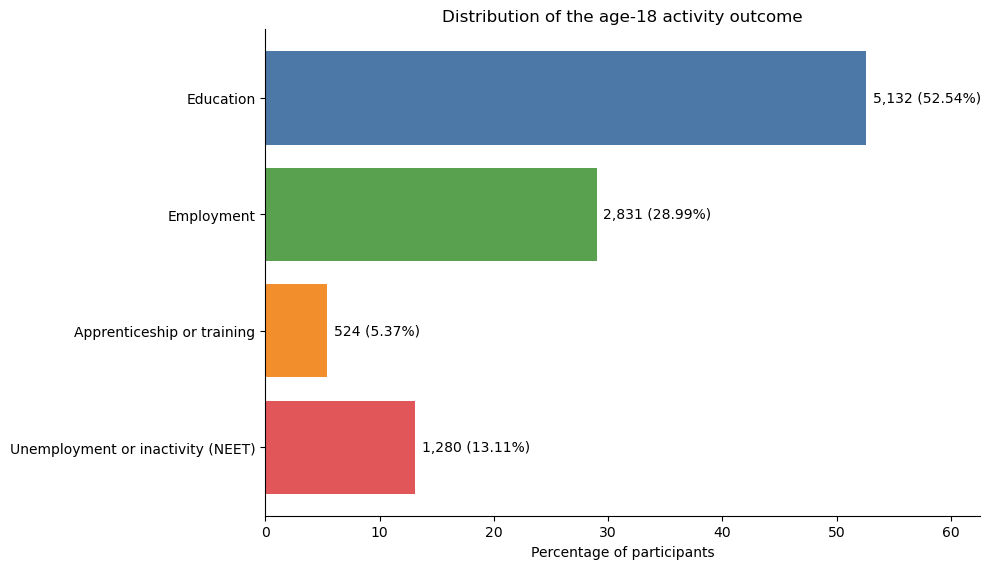

Figure file: age18_activity_outcome_distribution.png


In [5]:
# 2: Plot the outcome distribution

figure_output_directory = (
    project_root
    / "outputs"
    / "figures"
    / "stage_1_outcome_eda"
)

figure_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

outcome_figure_path = (
    figure_output_directory
    / "age18_activity_outcome_distribution.png"
)

outcome_colours = [
    "#4C78A8",
    "#59A14F",
    "#F28E2B",
    "#E15759",
]

fig, ax = plt.subplots(
    figsize=(10, 5.8)
)

bars = ax.barh(
    observed_distribution["age18_outcome"],
    observed_distribution["percentage"],
    color=outcome_colours,
)

ax.invert_yaxis()
ax.set_title("Distribution of the age-18 activity outcome")
ax.set_xlabel("Percentage of participants")
ax.set_ylabel("")
ax.set_xlim(
    0,
    observed_distribution["percentage"].max() + 10,
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, count, percentage in zip(
    bars,
    observed_distribution["count"],
    observed_distribution["percentage"],
):
    ax.text(
        bar.get_width() + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({percentage:.2f}%)",
        va="center",
    )

plt.tight_layout()
plt.savefig(
    outcome_figure_path,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Figure file:", outcome_figure_path.name)


## Outcome Distribution

The figure shows the marked difference in prevalence across the four age-18 activity statuses, with Education accounting for more than half of the valid outcome sample and Apprenticeship or training representing the smallest category. The four categories remain separate because they represent substantively different activities at age 18.

# Part 3: EDA Outputs


In [6]:
# 1: Save and verify the EDA outputs

table_output_directory = (
    project_root
    / "outputs"
    / "tables"
    / "stage_1_outcome_eda"
)

table_output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

class_balance_path = (
    table_output_directory
    / "age18_activity_outcome_class_balance.csv"
)

eda_summary_path = (
    table_output_directory
    / "age18_activity_outcome_eda_summary.csv"
)

outcome_eda_summary = pd.DataFrame(
    {
        "valid_outcome_n": [valid_outcome_n],
        "number_of_classes": [len(outcome_order)],
        "largest_class": [largest_class],
        "largest_class_n": [largest_class_n],
        "smallest_class": [smallest_class],
        "smallest_class_n": [smallest_class_n],
        "largest_to_smallest_ratio": [
            largest_to_smallest_ratio
        ],
        "majority_class_baseline_accuracy": [
            majority_class_baseline
        ],
    }
)

class_balance_summary.to_csv(
    class_balance_path,
    index=False,
)

outcome_eda_summary.to_csv(
    eda_summary_path,
    index=False,
)

class_balance_reloaded = pd.read_csv(
    class_balance_path
)

eda_summary_reloaded = pd.read_csv(
    eda_summary_path
)

if class_balance_reloaded["count"].sum() != valid_outcome_n:
    raise ValueError(
        "The saved class-balance table had an incorrect total."
    )

if not np.isclose(
    class_balance_reloaded["percentage"].sum(),
    100.0,
):
    raise ValueError(
        "The saved class percentages did not sum to 100."
    )

if eda_summary_reloaded.loc[0, "valid_outcome_n"] != valid_outcome_n:
    raise ValueError(
        "The saved EDA summary had an incorrect sample size."
    )

output_paths = {
    "Class-balance table": class_balance_path,
    "EDA summary": eda_summary_path,
    "Distribution figure": outcome_figure_path,
}

for output_name, output_path in output_paths.items():
    if not output_path.exists():
        raise FileNotFoundError(
            f"Missing output: {output_name} — {output_path}"
        )

print("Outcome EDA outputs")
print("-------------------")
print("Participants:", f"{valid_outcome_n:,}")
print("Classes:", len(outcome_order))
print(
    "Largest-to-smallest ratio:",
    f"{largest_to_smallest_ratio:.2f}:1",
)
print(
    "Stage 1 majority-class accuracy:",
    f"{majority_class_baseline:.2%}",
)
print()
print("Saved files:")
for output_name, output_path in output_paths.items():
    print(f"- {output_name}: {output_path.name}")


Outcome EDA outputs
-------------------
Participants: 9,767
Classes: 4
Largest-to-smallest ratio: 9.79:1
Stage 1 majority-class accuracy: 52.54%

Saved files:
- Class-balance table: age18_activity_outcome_class_balance.csv
- EDA summary: age18_activity_outcome_eda_summary.csv
- Distribution figure: age18_activity_outcome_distribution.png


## EDA Summary

| Measure | Result |
|---|---:|
| Valid Stage 1 outcome sample | 9,767 |
| Education | 5,132 (52.54%) |
| Employment | 2,831 (28.99%) |
| Apprenticeship or training | 524 (5.37%) |
| Unemployment or inactivity (NEET) | 1,280 (13.11%) |
| Largest-to-smallest ratio | 9.79:1 |
| Majority-class accuracy in this sample | 52.54% |

The outcome distribution was therefore clearly imbalanced before later modelling-sample restrictions were applied. This supports the use of class-sensitive evaluation metrics in the subsequent predictive modelling stages.